# Documentation
1. [Brush up for Fourier within image reconstruction context](https://thepythoncodingbook.com/2021/08/30/2d-fourier-transform-in-python-and-fourier-synthesis-of-images/)

# Utilities

In [1]:
from imports import *

# Assignment 

## Assignment 4.1

In [2]:
#TODO Build a proxi gradient step visualization
#TODO Build a gradient step visualization
train, valid, test = create_dataloaders(batch_size=64, data_loc='\DataLoc')
examples = enumerate(train)
_, (x_clean_example, x_noisy_example, labels_example) = next(examples)

<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
C:\Users\20240091\AppData\Local\Temp\ipykernel_15808\1658719758.py:3: SyntaxWarning: invalid escape sequence '\D'
  train, valid, test = create_dataloaders(batch_size=64, data_loc='\DataLoc')


PATH: \DataLoc
PATH: \DataLoc
PATH: \DataLoc


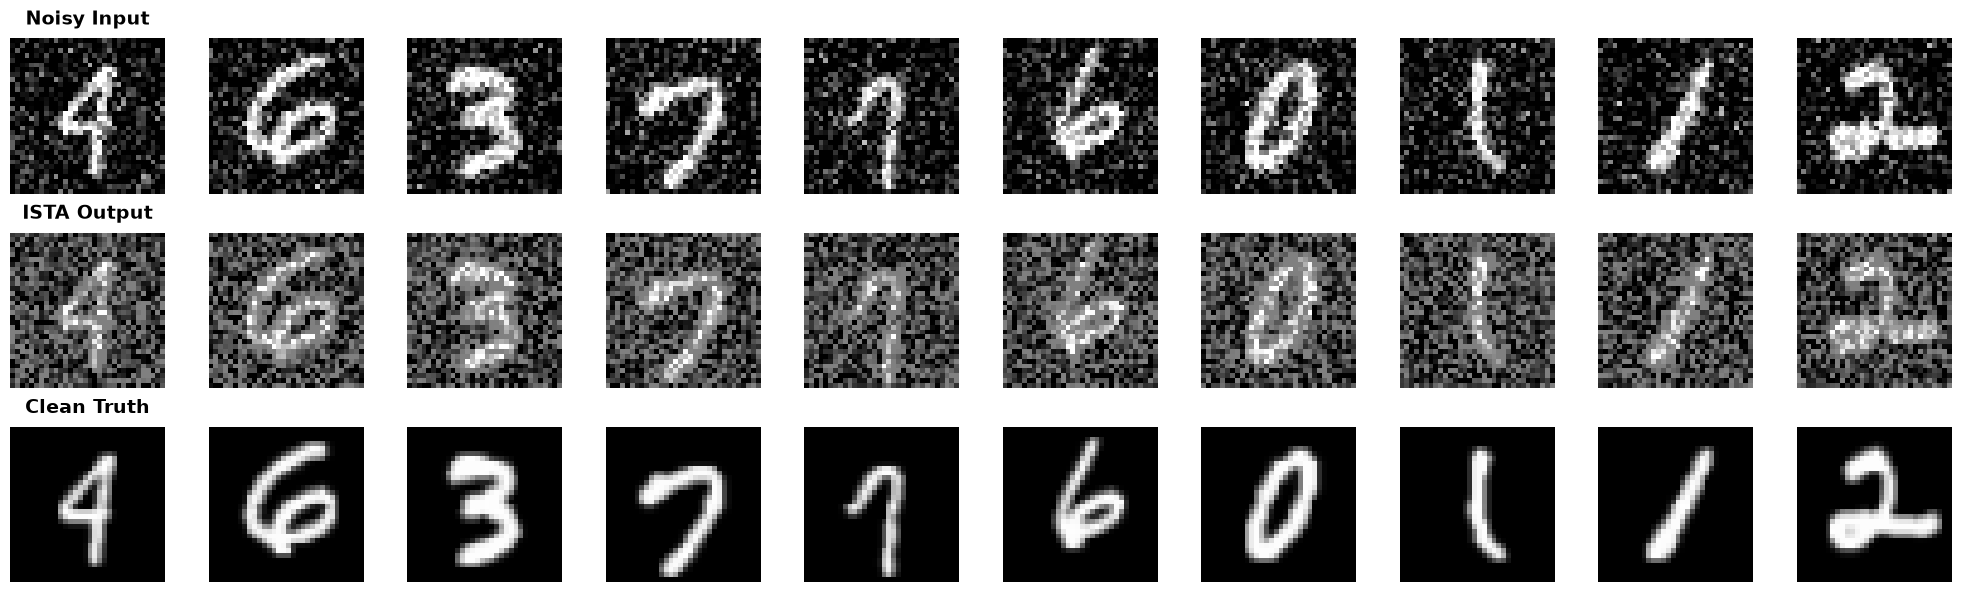

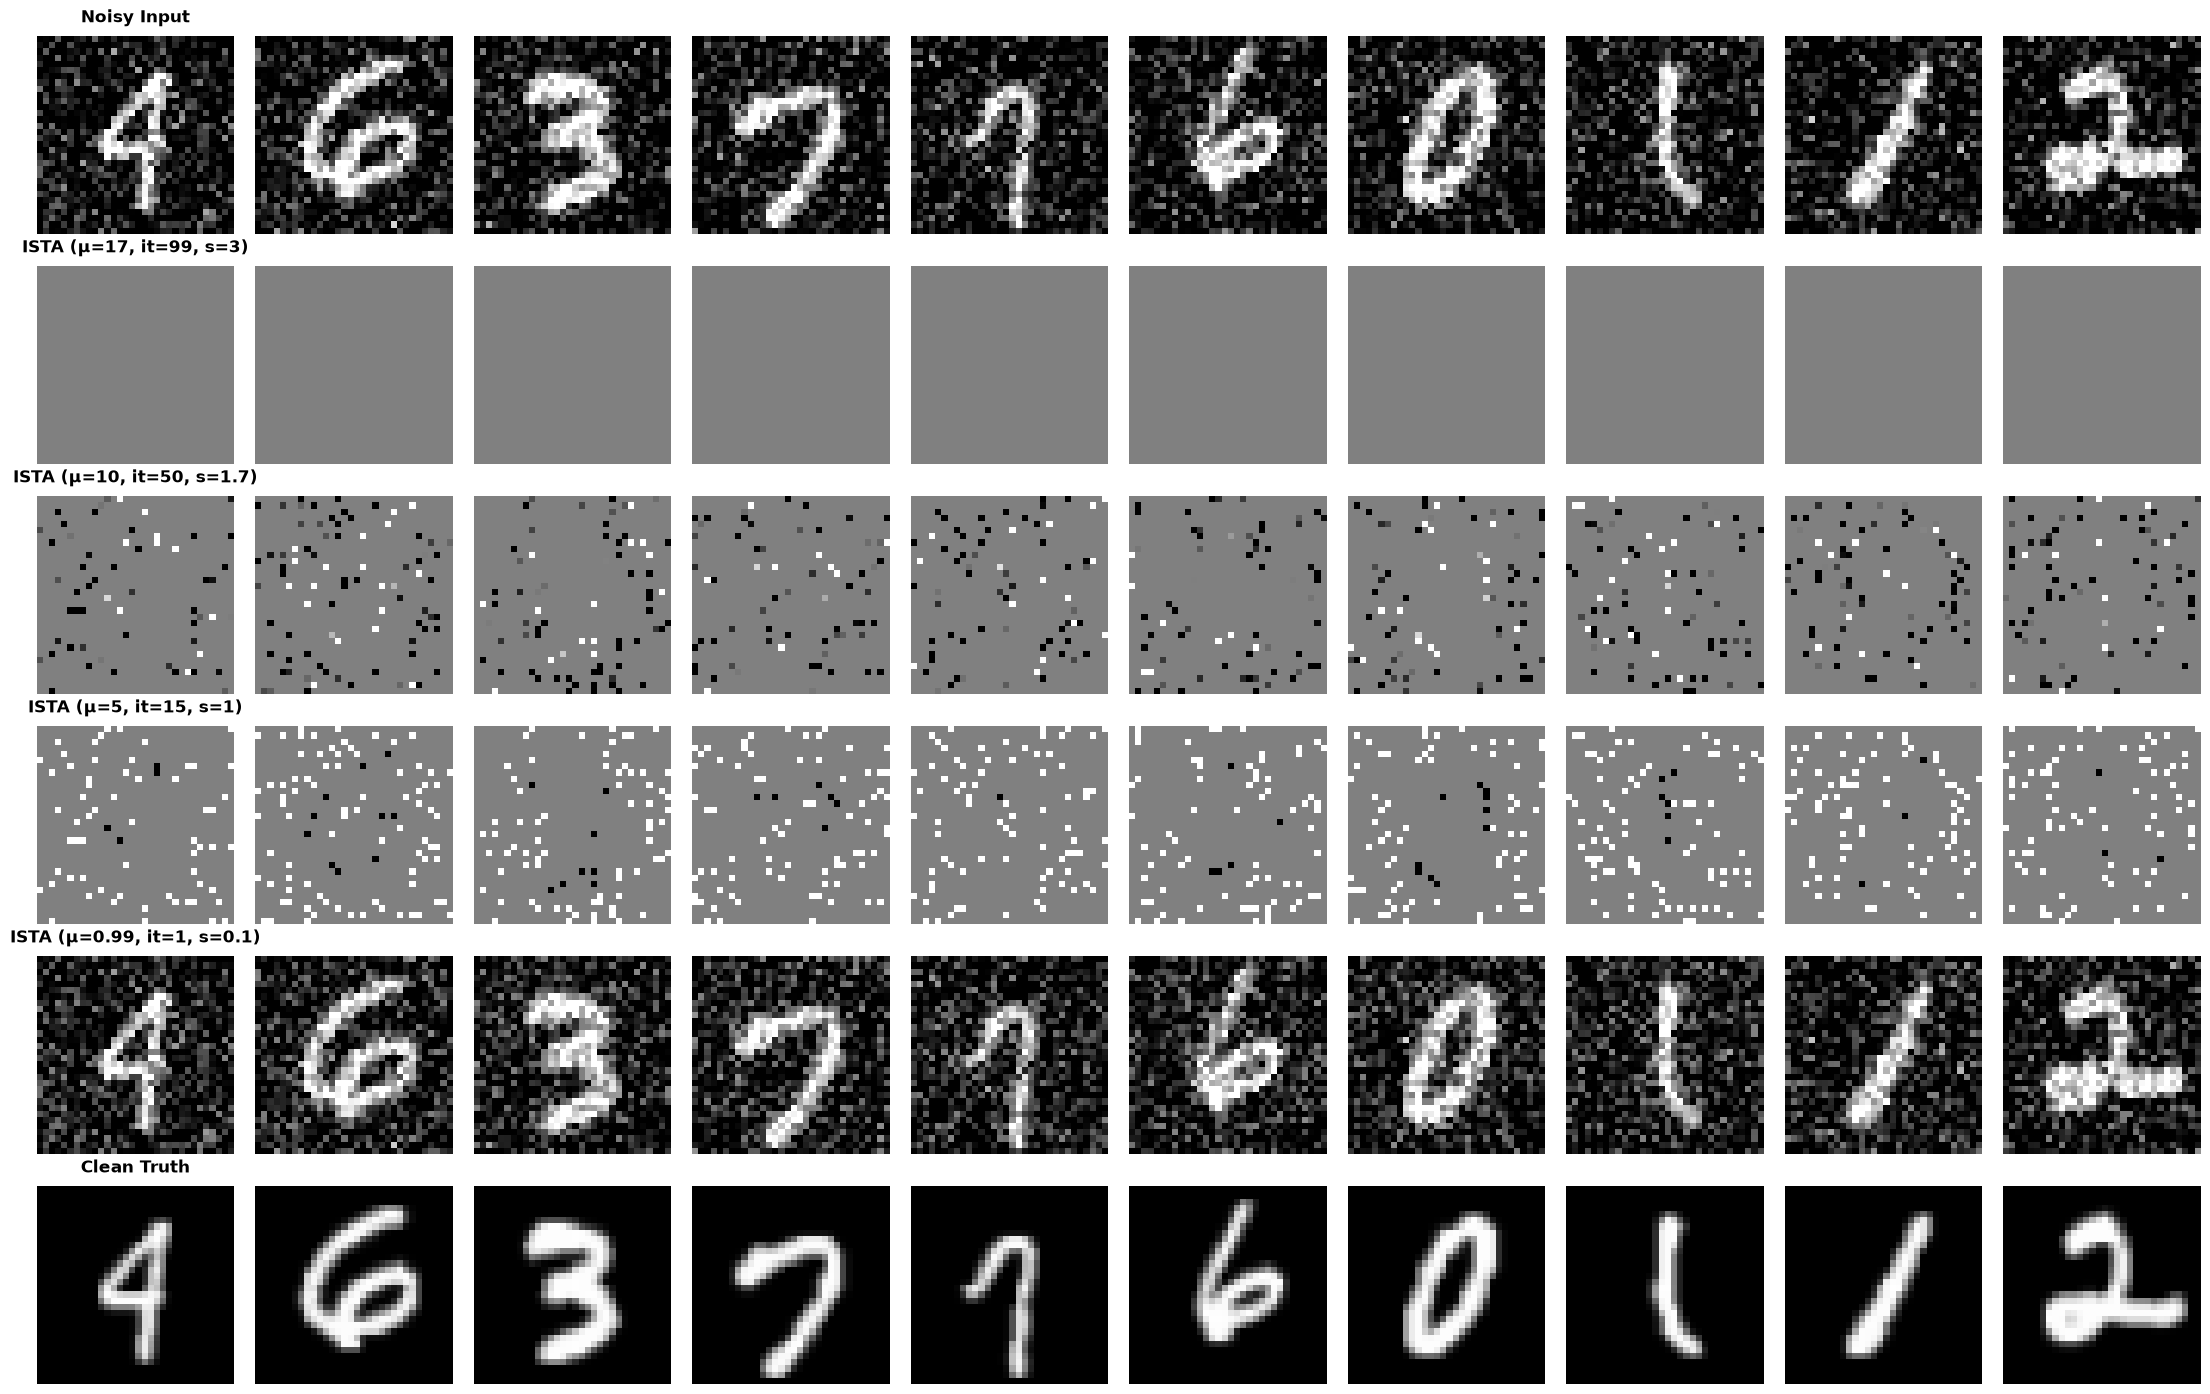

Regular value range of the images is max:1.0 and min:-1.0


In [13]:
# 1. Perform ISTA
#TODO Make this perform denoising task as well
ista_reconstructions = ista(miu=5, shrink=0.1, no_iterations=1, y=x_noisy_example)

# 2. Define image-holders variables;
noisy_np = x_noisy_example.squeeze()
recon_np = ista_reconstructions.squeeze()
clean_np = x_clean_example.squeeze()

# Under the suboptimal suit of hyperparameters (that includes both miu/step size and shrinkage/threshold) 
# increasing the number of iterations will do nothing else but to hinder and make the convergence divert even more from 
# the optimal course. The contrary is applicable. Under the optimal pair of hyperparameters, the number of iterations will not change the quality of the solution
# as the convergence was guaranted from the very beginning.
# Based on heuristic experimentation, I discovered that the convergence is mostly influenced by the shrinkage value, which should be lowered until 
# the point the thresholding interval is encapsulated by the measurement matrix interval (e.g., maximum and minimium pixel values fall outside of the thresholding
# limits). Once the optimal shrinking limit was identified corrupting the quality of the solution can be done by adopting a very exagerated value for miu (~ the step-size),
# that is large enough to create a significant departure from the found solution. Not only this effect gets amplified as the miu value grows larger but also
# worsen with increasing the number of iterations that make for an erornous extended walk (e.g., more steps) 

# Assuming x_noisy_example and x_clean_example are already loaded from your dataset
#TODO Document the behavior of the ista based on the parameters;


# Pull tensors back to CPU and convert to numpy for Matplotlib
#TODO Document the function again based on your commentaries
#TODO Dismantled extraneous code commands (e.g., squezee())

# 3. Displaying required results
fig, axes = PLT.subplots(nrows=3, ncols=10, figsize=(20, 6))
for i in range(10):
    # ROW 1: Noisy Measurement (y)
    axes[0, i].imshow(noisy_np[i], cmap='gray', vmin=-1, vmax=1)
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title("Noisy Input", fontsize=14, fontweight='bold', pad=10)
    
    # ROW 2: ISTA Reconstruction (x_K)
    axes[1, i].imshow(recon_np[i], cmap='gray', vmin=-1, vmax=1)
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title("ISTA Output", fontsize=14, fontweight='bold', pad=10)
    
    # ROW 3: Ground Truth Target (x)
    axes[2, i].imshow(clean_np[i], cmap='gray', vmin=-1, vmax=1)
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_title("Clean Truth", fontsize=14, fontweight='bold', pad=10)

PLT.tight_layout()
PLT.show()

# 4. Defining the experiment-setting variable holders and 
# ...displaying experimental results
miu:list = [17, 10, 5, 0.99]
no_iterations:list = [99, 50, 15, 1]
shrink:list = [3, 1.7, 1, 0.1]

# 4.1 Setup a clean grid: 1 Row for Noisy, 4 Rows for Experiments, 1 Row for Clean Truth = 6 Rows total
fig, axes = PLT.subplots(nrows=6, ncols=10, figsize=(22, 14))
for i in range(10):
    # ROW 0: Noisy Measurement (y)
    axes[0, i].imshow(noisy_np[i], cmap='gray', vmin=-1, vmax=1)
    axes[0, i].axis('off')
    if i == 0: 
        axes[0, i].set_title("Noisy Input", fontsize=12, fontweight='bold', pad=10)

    # ROW 5: Ground Truth Target (x)
    axes[5, i].imshow(clean_np[i], cmap='gray', vmin=-1, vmax=1)
    axes[5, i].axis('off')
    if i == 0: 
        axes[5, i].set_title("Clean Truth", fontsize=12, fontweight='bold', pad=10)

for experiments in range(4):
    # FIXED: accurately passed shrink=shrink[experiments] instead of duplicating miu
    ista_reconstructions = ista(
        miu=miu[experiments], 
        shrink=shrink[experiments], 
        no_iterations=no_iterations[experiments], 
        y=x_noisy_example
    )
    
    # Safely detach and squeeze if dealing with PyTorch tensors
    recon_np = ista_reconstructions.detach().cpu().numpy().squeeze() if hasattr(ista_reconstructions, 'detach') else ista_reconstructions.squeeze()

    # Calculate active row (Rows 1, 2, 3, and 4 are reserved for the 4 experiments)
    current_row = experiments + 1

    for i in range(10):
        axes[current_row, i].imshow(recon_np[i], cmap='gray', vmin=-1, vmax=1)
        axes[current_row, i].axis('off')
        
        if i == 0:
            title_text = f"ISTA (μ={miu[experiments]}, it={no_iterations[experiments]}, s={shrink[experiments]})"
            axes[current_row, i].set_title(title_text, fontsize=12, fontweight='bold', pad=10)

PLT.tight_layout()
PLT.show()

# Informative print;
print("Regular value range of the images is max:{} and min:{}".format(x_clean_example.max(), x_clean_example.min()))

## Assignment 4.2

In [23]:
# TODO Create parser
train, valid, test = create_dataloaders(batch_size=64, data_loc='\DataLoc')
model = LISTA(1, 1, 3)
optim = SGD(model.parameters(), lr=0.001) 
loss_fn = nn.MSELoss()
epochs:int = 10
train_history, val_history, new_best = [], [], 0

for epoch in range(epochs):
    ### 1. Training == ######
    # Initializing training #                    
    ############### == ######
    model.train()
    reconstruction_acc_train, reconstruction_acc_val = 0.0 ,0.0
    for batch_idx, (x_clean, x_noisy, label) in enumerate(tqdm.tqdm(train, desc=f"Epoch {epoch+1}/{epochs} [Train]")):
        optim.zero_grad() # 1.1 Cleaning gradient cache memory;
        # 1.2
        # y is the measurement (noisy image). 
        # x is the initial state. The typical initialization is x_0 = 0.
        x_init = torch.zeros_like(x_noisy)
        _rec = model(x=x_init, y=x_noisy)
        # You correctly mapped the supervised target to x_clean!
        _loss = loss_fn(_rec, x_clean)
        # 1.3
        # Calculate the gradients and update the weights
        _loss.backward() # Backprop
        optim.step() # Gradient step
        
        reconstruction_acc_train+=_loss.item()

    ### 2. Validation == #######
    # Initializing validation ##                    
    ############### == #########
    model.eval()
    with torch.no_grad():
        for batch_idx, (x_clean, x_noisy, label) in enumerate(tqdm.tqdm(valid, desc=f"Epoch {epoch+1}/{epochs} [Valid]")): 
            
            # Apply the same initialization fixes to the validation loop
            x_init = torch.zeros_like(x_noisy)
            _rec = model(x=x_init, y=x_noisy)
            
            _loss = loss_fn(_rec, x_clean)
            reconstruction_acc_val+=_loss.item()

    batch_rec_acc_train = reconstruction_acc_train/len(train)
    train_history.append(batch_rec_acc_train)
    batch_rec_acc_valid = reconstruction_acc_val/len(valid)
    val_history.append(batch_rec_acc_valid)
    best = batch_rec_acc_valid
    
    # Informative prints
    print(f"Epoch {epoch+1}: Train Averaged MSELoss {batch_rec_acc_train:.4f} | Valid Averaged MSELoss {batch_rec_acc_valid:.4f}")
    torch.save(model.state_dict(), r'results\newest_variant.pth')

    if 1-best > new_best:
        new_best = best
        torch.save(model.state_dict(), r'results\best_model.pth')
        


<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\20240091\AppData\Local\Temp\ipykernel_644\231749892.py:2: SyntaxWarning: invalid escape sequence '\D'
  train, valid, test = create_dataloaders(batch_size=64, data_loc='\DataLoc')


PATH: \DataLoc
PATH: \DataLoc
PATH: \DataLoc


Epoch 1/10 [Valid]: 100%|██████████| 157/157 [00:00<00:00, 235.34it/s]


Epoch 1: Train Averaged MSELoss 0.1603 | Valid Averaged MSELoss 0.0748


Epoch 2/10 [Valid]: 100%|██████████| 157/157 [00:00<00:00, 214.05it/s]


...

Epoch 8: Train Averaged MSELoss 0.0480 | Valid Averaged MSELoss 0.0475


Epoch 9/10 [Valid]: 100%|██████████| 157/157 [00:00<00:00, 206.32it/s]


Epoch 9: Train Averaged MSELoss 0.0474 | Valid Averaged MSELoss 0.0469


Epoch 10/10 [Valid]: 100%|██████████| 157/157 [00:00<00:00, 218.05it/s]

Epoch 10: Train Averaged MSELoss 0.0469 | Valid Averaged MSELoss 0.0465


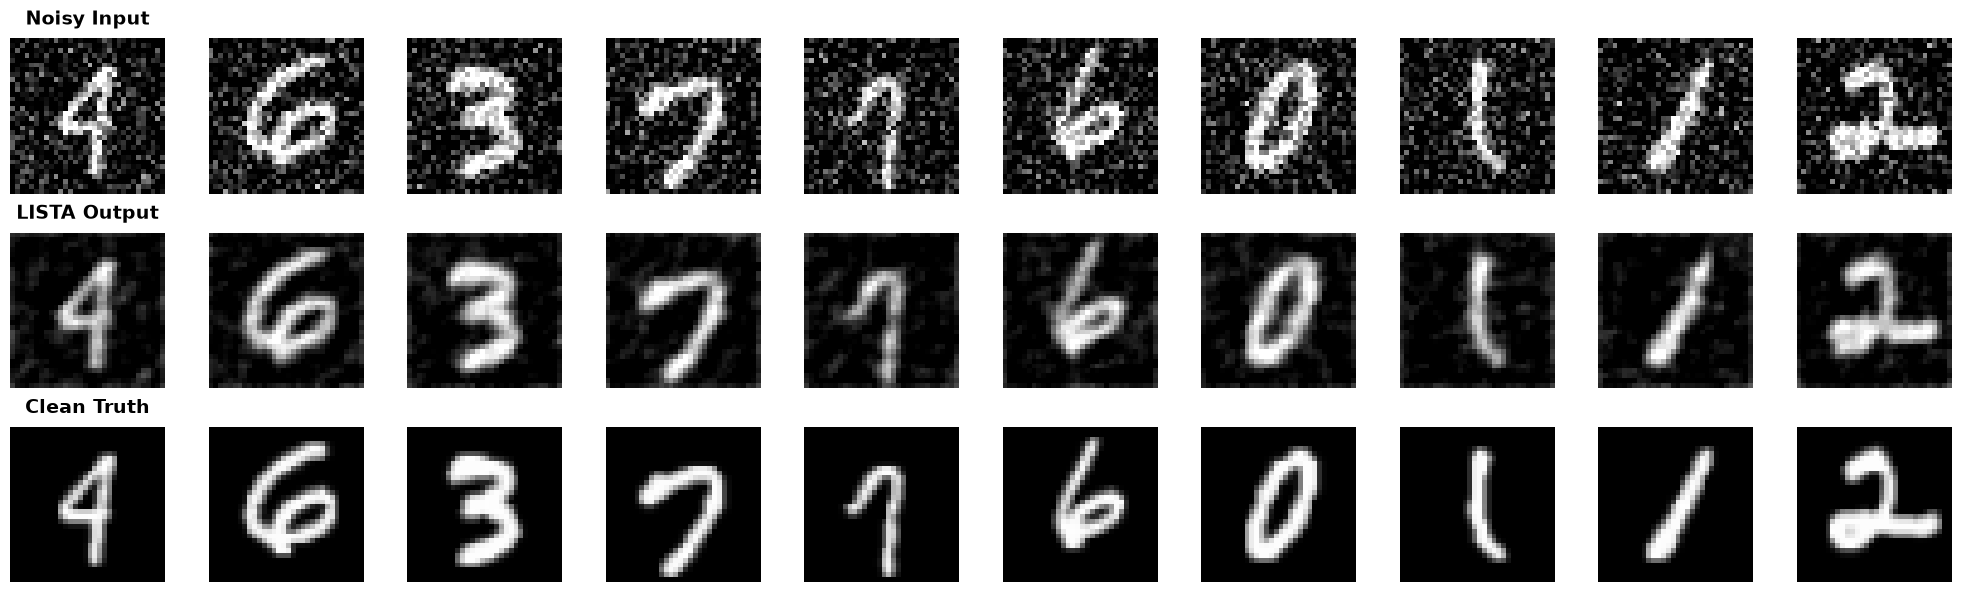

In [28]:
# 1. Loading the weights and initialize the network
model = LISTA(1, 1, 3) # NETWORK init
weights = torch.load(r'results\best_model.pth', weights_only=True) # LOADING weights
model.load_state_dict(weights) # INJECTING weights

###### === ########
# Evaluation Mode #
###### === ########
model.eval() 
with torch.no_grad():
    x_init = torch.zeros_like(x_noisy_example)
    lista_reconstructions = model(x=x_init, y=x_noisy_example)

rec = lista_reconstructions.squeeze()
noisy = x_noisy_example.squeeze()
clean=x_clean_example.squeeze()

# 3. Displaying required results
fig, axes = PLT.subplots(nrows=3, ncols=10, figsize=(20, 6))
for i in range(10):
    # ROW 1: Noisy Measurement (y)
    axes[0, i].imshow(noisy[i], cmap='gray', vmin=-1, vmax=1)
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title("Noisy Input", fontsize=14, fontweight='bold', pad=10)
    
    # ROW 2: ISTA Reconstruction (x_K)
    axes[1, i].imshow(rec[i], cmap='gray', vmin=-1, vmax=1)
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title("LISTA Output", fontsize=14, fontweight='bold', pad=10)
    
    # ROW 3: Ground Truth Target (x)
    axes[2, i].imshow(clean[i], cmap='gray', vmin=-1, vmax=1)
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_title("Clean Truth", fontsize=14, fontweight='bold', pad=10)

PLT.tight_layout()
PLT.show()

In [ ]:
# 1. Load the model weights and initialize the network
weights = torch.load(r'results\best_model.pth', weights_only=True) # Weights LOAD
model = LISTA(1,1,3) # Model INIT
model.load_state_dict(weights)

# 2. Switch to evaluation mode; 
model.eval()
with torch.no_grad():
    for batch_idx, (clean, noisy, label) in enumerate(tqdm.tqdm(test, desc=f"[Test]")):
        x_init = torch.zeros_like(noisy)
        _rec = model(x=x_init, y=noisy)
        _loss = loss_fn(_rec, clean)

print("MSE numerical estimate for the performance on testset:", _loss/len(test))

# The problem I almost worked out is displayed by the attachment (e.g., the snippet) above. 
# By the book, I understood that LISTA relies upon a somewhat similar shrinkage mechanism as the one ISTA is using. 
# This mechanism, pragmatically talking, consists from two welded back-to-back ReLU functions, each taking a 
# positively and negatively input: ReLU(u+\theta)-ReLU(-u-\theta). 
# So, without a shadow of doubt, within the context as defined by LISTA where two learnable kernels Wx and Wy 
# are being summed up and subsequently passed through such a shrinkage function, I would safety assumed that 
# a non-linear function lies at the core of working principle LISTA makes use of.

[Test]: 100%|██████████| 157/157 [00:00<00:00, 224.07it/s]

MSE numerical estimate for the performance on testset: tensor(0.0003)


## Assignment 4.3

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:01<?, ?it/s]


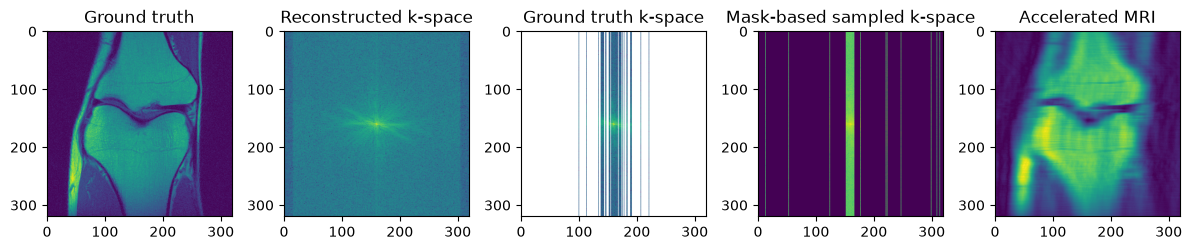

In [7]:
train_MRI, test_MRI = create_dataloaders_MRI(batch_size=64, data_loc=r'CodeForStudents4\Fast_MRI_Knee')
for batch_idx, (kspace, M, X) in enumerate(tqdm.tqdm(train_MRI)):
    img = X[0]
    rec_kspace = get_k_space(X[0])
    sampled_k_space = kspace[0]
    mask_sampled_kspace, _ = get_partial_k_space(get_k_space(X)) 
    accelerated_MRI = get_accelerated_MRI(mask_sampled_kspace)
    break

fig, axis = PLT.subplots(1,5, figsize=(12,5))
# save_log = torch.log(torch.abs(mask_sampled_kspace[0].to_dense()) + 1e-9)
# k_min = save_log.real.min().item()
# k_max = save_log.real.max().item()

axis[0].imshow(img)
axis[0].set_title('Ground truth')
axis[1].imshow(torch.log(torch.abs(rec_kspace)))
axis[1].set_title('Reconstructed k-space')


axis[2].imshow(torch.log(torch.abs(sampled_k_space))) # The result of the FFT is an array of complex numbers. 
# This is why you plot the absolute value of the Fourier transform ft, using the abs() built-in function. 
# Note that you’re only doing this for the purposes of displaying the Fourier transform. 
# You are not discarding the complex information from the array ft.
axis[2].set_title('Ground truth k-space')
# You display the logarithm of the Fourier transform using np.log() as this allows you to see what’s 
# going on better. Without this change, the constant term at the centre of the Fourier transform would be so 
# much brighter than all the other points that everything else will appear black. You’d be “blinded” by this one, central dot.


# === The sampled K-space
safe_log = torch.log(torch.abs(mask_sampled_kspace[0].to_dense()) + 1e-9)
axis[3].imshow(safe_log)
axis[3].set_title('Mask-based sampled k-space')

# === The reconstructed image
axis[4].imshow(torch.abs(accelerated_MRI[0].squeeze()))
axis[4].set_title('Accelerated MRI')


PLT.tight_layout()
PLT.show()

### An overlapping effect caused by sampling—often known as sample overlap bias or 
# spurious correlation—occurs when the same individuals or datasets are unknowingly 
# reused across different stages of a statistical or machine learning analysis 
# (e.g., in GWAS, Polygenic Risk Scores, or Mendelian Randomization). 
# This re-use leads to inflated effect sizes, false positives, and overfitted models


## Assigment 4.4

  0%|          | 0/4 [00:00<?, ?it/s]

Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19
Iteration 20
Iteration 21
Iteration 22
Iteration 23
Iteration 24
Iteration 25
Iteration 26
Iteration 27
Iteration 28


  0%|          | 0/4 [00:09<?, ?it/s]

Iteration 29


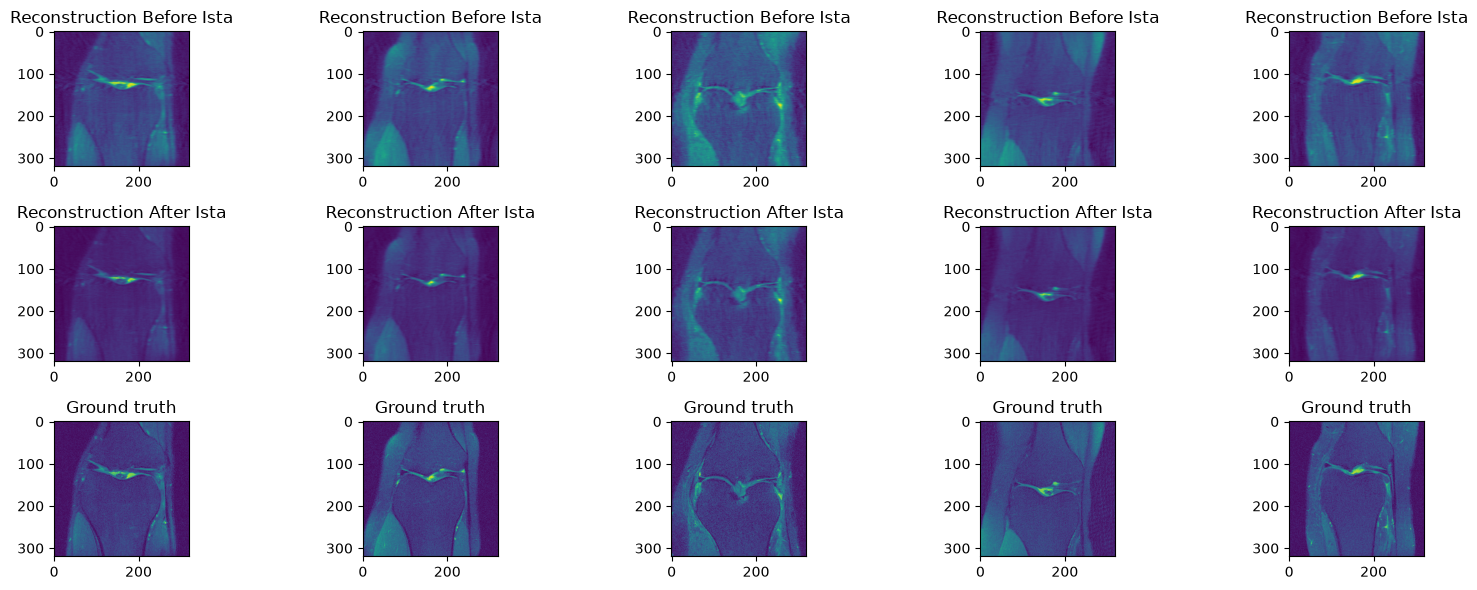

In [38]:
for idx, (kspace, M, gt) in enumerate(tqdm.tqdm(test_MRI)):
    batch_of_k_space_measurements = kspace
    _, batch_of_measurement_mask = get_partial_k_space(batch_of_k_space_measurements) 
    x_rec, x_rec_before = ista_mri(
    miu=1.0,          # Perfect projection onto known k-space
    shrink=3,     # Lowered to preserve soft tissue/cartilage details
    iter=30,          # Increased to clear out residual ghosting lines
    k_space_measurements=batch_of_k_space_measurements,
    k_space_measurement_masks=M
)
    break


fig, axis = PLT.subplots(3,5, figsize=(16,6))
for rows in range(5):
    # --- Before ISTA --- #
    axis[0,rows].imshow(x_rec_before.real[rows])
    axis[0, rows].set_title("Reconstruction Before Ista")
    # --- After ISTA --- # 
    axis[1,rows].imshow(x_rec.real[rows])
    axis[1, rows].set_title("Reconstruction After Ista")
    # --- Ground Truth --- #
    axis[2,rows].imshow(gt[rows])
    axis[2,rows].set_title('Ground truth')
PLT.tight_layout()

## Assignment 4.5

In [45]:
mock_torch = torch.empty(1, 64, 320, 320)
print("shape {}".format(mock_torch.permute((1,0,2,3)).shape))

shape torch.Size([64, 1, 320, 320])


  0%|          | 0/4 [00:07<?, ?it/s]


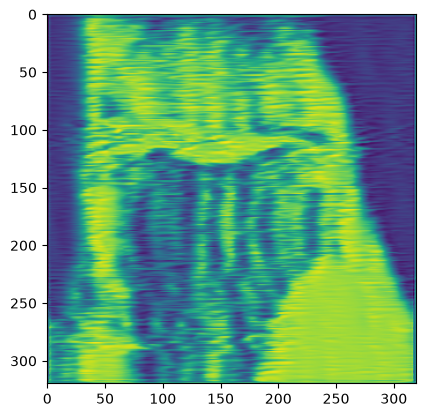

In [ ]:
# Model and exerimental settings setup
# 1.1 Initializing the model, optimizer, loss and its architecture hyper-parameters
model = ConvISTA(pading='same',
                 stride=1,
                 kernel_size=3, 
                 width=[1,12,24,12,1])
loss = MSELoss()
optim = SGD(model.parameters(), lr=0.01)

# 1.2 Check the architecture by reviewing the displayed summary
summary(model)
# 1.3 Load the data and declare history holder containers
train_MRI, test_MRI = create_dataloaders_MRI(batch_size=64, data_loc=r'CodeForStudents4\Fast_MRI_Knee')
train_loss, val_loss =[], []

for epoch in range(epochs):
    ###### === #######
    # Model Training #
    ###### === #######      
    val_loss_counter, train_loss_counter = 0.0, 0.0
    model.train()
    for idx, (kspace, M, gt) in enumerate(tqdm.tqdm(test_MRI)):
        # TODO wrap this preprocessing step in a helper function
        # 1. X is to be perceived as a complete K-space (e.g. unprocessed K-space),
        # for which sampling will be applied to obtain the partial k-space and its associated reconstruction
        partial_k_space, _ = get_partial_k_space(k_space)
        x_rec = get_accelerated_MRI(partial_k_space)
        _train_rec = model(x_rec)
        _train_loss = loss(_train_rec, gt)
        _train_loss.backward() # backprop
        # optim-step


    reconstruction = model(kspace)
    break
PLT.imshow(reconstruction[0].detach().squeeze(0))


# Helpers or standalone methods

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:06<?, ?it/s]


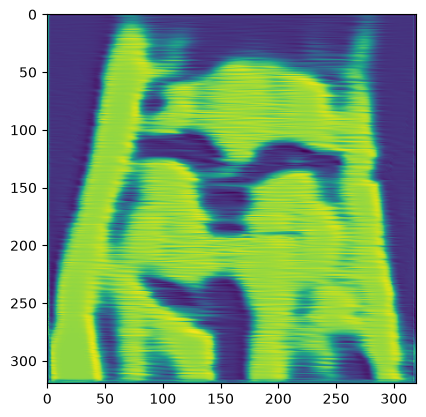

In [ ]:
#TODO make sure that you're displaying the right images;
class ConvISTA(nn.Module):
    """
    Requirements: As a starting point for a deep learning solution, design an end-to-end convolutional neural network. 
    As input it should take an initial reconstruction from a partial k-space measurement and output a guess for the 
    final reconstruction. The net is not (yet) allowed to make use of knowledge about the sampling mask.
    """
    def __init__(self, pading:str|int, stride:int, kernel_size:int|tuple, width:list|int, layers:int = 4):
        super().__init__()
        # 1. Listing out the variables used to define the network's architecture
        self.NETWORK = nn.Sequential()
        self.width = width
        self.layers = layers

        self.pading = pading
        if type(self.pading) != list:
            self.pading = [pading for item in range(layers)]
        self.stride = stride

        self.ken_size = kernel_size
        if type(self.ken_size) != list:
            self.ken_size = [kernel_size for item in range(layers)]


        for layer in range(layers):
            self.NETWORK.append(nn.Conv2d(in_channels=width[layer], 
                                          out_channels=width[layer+1], 
                                          kernel_size=self.ken_size[layer],
                                          padding=self.pading[layer]))
            self.NETWORK.append(nn.BatchNorm2d(width[layer+1]))
            if layer != layers-1:
                self.NETWORK.append(nn.Tanh())
            else: 
                self.NETWORK.append(nn.Sigmoid())


    def forward(self, x):
        x_final_rec = self.NETWORK(torch.abs(x_rec).unsqueeze(1))

        return x_final_rec

In [ ]:
class LISTA(nn.Module):
    def __init__(self, in_c, out_c, k):
        super().__init__()
        self.in_channel = in_c
        self.out_channel = out_c
        self.no_folds = k
        self.network = nn.ModuleList() # In the nn.Sequential() container we do have the forward() method implementation but in the case of 
                                       # nn.ModuleList() this mechanism is absent therefore for each layer an explicit call is required;)
        # . By drawing upon a list comprehension mechanism separately defining the learnable convolutional matrices Wx and Wy becomes possible
        self.Wx = nn.ModuleList([nn.Conv2d(in_channels=self.in_channel, out_channels=self.out_channel, kernel_size=3, padding='same') for _ in range(self.no_folds)])
        self.Wy = nn.ModuleList([nn.Conv2d(in_channels=self.in_channel, out_channels=self.out_channel, kernel_size=3, padding='same') for _ in range(self.no_folds)])
        self.lambd = nn.Parameter(torch.randn(self.no_folds))

    def forward(self, x, y):
        for layer in range(self.no_folds):
            u = self.Wx[layer](x) + self.Wy[layer](y)
            x  = self.shrinkage(x = u, lam = self.lambd[layer])
            
        return x 
    
    def shrinkage(self, x, lam):
        return x + 0.5 * (torch.sqrt((x-lam)**2+1)-torch.sqrt((x+lam)**2+1))
    
# Testing
model = LISTA(in_c=1, out_c=1, k=3)
batch_sample = next(enumerate(train))
batch_idx, (clean, noisy, label) = batch_sample
ista_reconstructions=model(noisy, clean)
PLT.imshow(ista_reconstructions[0].detach().squeeze())


NameError: name 'train' is not defined

In [8]:
@staticmethod
def ista(miu:float, shrink:float, no_iterations:int, y:torch.tensor, MODE='ISTA')->torch.tensor:

    # 1.1 Wrap the required definitions in a private function,
    # ... of the members used in both, gradient and proximal steps;
    def _proximal_elements_definition(measurement=y):
        A_def:float = 1.0
        L_def:float = 1.0
        # 1.2 Initialize the unknown signal X to match the measurement shape
        x_def = measurement.clone() 
        return L_def, A_def, x_def
        
    L, A, X = _proximal_elements_definition() # L is required to define the threshold

    # 2.1 Defining shrinkage function
    def shrinkage_fn(current_x, lambd=shrink, measurement=y):
        # 2.2 Incorporating the required step size `miu` into the scalar terms
        W_y = miu * A 
        W_x = 1.0 - (miu * A * A)
        theta = lambd * miu

        # 2.3 ReLU definition wrapped in a private function;
        # Matrix multiplications (@) replaced with scalar multiplications (*)
        u = W_y * measurement + W_x * current_x
        
        # Accommodating the -1 background hint natively
        u_shifted = u + 1.0 
        
        # Using F.relu to cleanly process the maximum condition
        rec = F.relu(u - theta) - F.relu(-u - theta)
        
        # Shift back to the -1 background
        # rec = rec - 1.0

        return rec, (W_y, W_x, theta)

    for iter in range(no_iterations):
        # Update the evolving signal X, while keeping the original measurement y fixed
        X, _ = shrinkage_fn(current_x=X)

    return X

## 4.3 MRI Helper Functions

In [ ]:
@staticmethod
def get_partial_k_space(k_space: torch.Tensor) -> torch.Tensor:

    # 1. Determine the general size, meaning shape and number of columns
    matrix_shape = k_space.shape 
    num_columns = matrix_shape[-1]
    
    # 2. The definition of a dense center block becomes of necessity since 
    # a good deal of the image content/signal has its place of origin there

    center_width: int = 15  # Width of the fully sampled center
    center_start = (num_columns - center_width) // 2
    center_end = center_start + center_width
    center_indices = torch.arange(center_start, center_end, device=k_space.device)
    
    # 3.  Gather remaining edge indices and sample randomly
    edge_indices = torch.cat([
        torch.arange(0, center_start, device=k_space.device),
        torch.arange(center_end, num_columns, device=k_space.device)
    ])
    num_edge_cols: int = 10  # Number of random columns to pick from edges
    random_edge_selection = torch.randperm(len(edge_indices), device=k_space.device)[:num_edge_cols]
    sampled_edge_indices = edge_indices[random_edge_selection]
    
    # 4. Combine both steps
    active_col_indices = torch.cat([center_indices, sampled_edge_indices])
    
    # 5. Construct the mask using the combined indices
    mask_1d = torch.zeros(num_columns, dtype=k_space.dtype, device=k_space.device)
    mask_1d[active_col_indices] = 1.0
    
    # 6. Apply via broadcasting
    measurement_matrix_M = mask_1d.view(1, 1, -1)
    partial_k_space = k_space * measurement_matrix_M

    return partial_k_space, measurement_matrix_M

@staticmethod
def get_k_space(MRI_imgs: torch.Tensor) -> torch.Tensor:
    # 1. Transform straight from standard image to frequency domain
    k_space = torch.fft.fft2(MRI_imgs)
    k_space = torch.fft.fftshift(k_space, dim=(-2, -1))
    return k_space

@staticmethod
def get_accelerated_MRI(partial_k_space: torch.Tensor) -> torch.Tensor:
    # 1. Un-center the k-space back to standard FFT format
    ift = torch.fft.ifftshift(partial_k_space, dim=(-2, -1))
    # 2. Transform back to the spatial image domain
    accelerated_MRI = torch.fft.ifft2(ift)
    
    return accelerated_MRI



In [6]:
def ista_mri(miu: float, shrink: float, iter: int, k_space_measurements, k_space_measurement_masks):
    # 1. Initialize to zero in the image domain as a real-valued tensor
    # Using .real ensures the data type matches the real float output of get_accelerated_MRI
    x_init = torch.zeros_like(k_space_measurements).real
    
    for iteration in range(iter):
        # 2. Map image back to complex k-space: F(X)
        current_k_space = get_k_space(x_init)
        # 3. Calculate: \mu * M \odot F(X)
        partial_k_space = miu * k_space_measurement_masks * current_k_space
        # 4. Calculate: \mu * M \odot F(Y)
        real_k_space = miu * k_space_measurement_masks * k_space_measurements
        # 5. Combine data consistency terms inside the brackets
        u = current_k_space - partial_k_space + real_k_space
        
        # 6. Apply inverse Fourier transform and strict absolute value: |F^-1(...)|
        # get_accelerated_MRI handles the F^-1 and returns the real part
        x_c = torch.abs(get_accelerated_MRI(u))
        x_c_before_ISTA = x_c

        # 7. Standard mathematical Soft-Thresholding (Shrinkage)
        x_c = x_c + 0.5 * (torch.sqrt((x_c-shrink)**2+1)-torch.sqrt((x_c+shrink)**2+1))
        
        # Update the guess for the next iteration
        
        x_init = x_c
        
        print(f"Iteration {iteration}")
        
    return x_c, x_c_before_ISTA